# Stage 05 — HELOC SHAP Explanations

This notebook applies native XGBoost SHAP contributions to the complete frozen test partition and fixed 20-case cohort. It does not retrain the model, refit preprocessing, create a split, or run another XAI method.

## 1. Frozen transformer compatibility

The Stage 03 transformer is repeated unchanged so the frozen preprocessor can be loaded. Only its transform method is used.

In [1]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.special import expit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.utils.validation import check_is_fitted

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

class HELOCSpecialValuePreprocessor(BaseEstimator, TransformerMixin):
    """Median-impute HELOC measurements and append training-observed special-code indicators."""
    def __init__(self, feature_names, special_codes=(-7, -8, -9)):
        self.feature_names = feature_names
        self.special_codes = special_codes

    def fit(self, X, y=None):
        frame = self._frame(X)
        self.feature_names_in_ = np.asarray(self.feature_names, dtype=object)
        self.indicator_pairs_ = [(feature, int(code)) for feature in self.feature_names for code in self.special_codes if frame[feature].eq(code).any()]
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes))
        self.imputer_ = SimpleImputer(strategy="median", keep_empty_features=True)
        self.imputer_.fit(numeric); self.n_features_in_ = len(self.feature_names)
        return self

    def transform(self, X):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"]); frame = self._frame(X)
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes))
        imputed = self.imputer_.transform(numeric)
        indicators = np.column_stack([frame[feature].eq(code).astype(np.int8).to_numpy() for feature, code in self.indicator_pairs_]) if self.indicator_pairs_ else np.empty((len(frame), 0), dtype=np.int8)
        return np.hstack([imputed, indicators]).astype(float, copy=False)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"])
        return np.asarray([f"{feature}__numeric_imputed" for feature in self.feature_names] + [f"{feature}__is_minus{abs(code)}" for feature, code in self.indicator_pairs_], dtype=object)

    def _frame(self, X):
        if isinstance(X, pd.DataFrame):
            missing = set(self.feature_names) - set(X.columns)
            if missing: raise ValueError(f"Missing required features: {sorted(missing)}")
            return X.loc[:, self.feature_names].copy()
        return pd.DataFrame(X, columns=self.feature_names)

## 2. Reconstruct and verify the frozen test data

The immutable snapshot, saved test indexes and frozen artifacts reconstruct all 1,974 holdout rows. No rows are sampled for global SHAP analysis.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "heloc": PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == "ml": PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "backend": PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "backend" / "data" / "heloc" / "raw" / "heloc_raw.csv"
ARTIFACT_DIR = PROJECT_ROOT / "backend" / "artifacts" / "heloc"; PLOT_DIR = ARTIFACT_DIR / "plots"
EXPECTED_HASH = "786b7e1885cf508ef66a968aae65a72bfde198d06d7666ac582958705b092570"
TARGET = "is_at_risk"; THRESHOLD = 0.50; SPECIAL_CODES = (-7, -8, -9)

paths = {name: ARTIFACT_DIR / filename for name, filename in {
    "selection": "selected_features.json", "excluded_all9": "excluded_all_minus9_indices.csv",
    "excluded_duplicates": "excluded_duplicate_indices.csv", "train_indices": "train_indices.csv",
    "test_indices": "test_indices.csv", "preprocessor": "preprocessor.joblib",
    "preprocessing_metadata": "preprocessing_metadata.json", "mapping": "transformed_feature_mapping.csv",
    "model": "xgboost_credit_model.joblib", "model_metadata": "model_metadata.json", "xai_cases": "xai_evaluation_cases.csv"}.items()}
for path in paths.values():
    if not path.exists(): raise FileNotFoundError(path)
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_HASH

raw_df = pd.read_csv(RAW_PATH)
selection = json.loads(paths["selection"].read_text(encoding="utf-8")); selected_features = selection["selected_features"]
preprocessing_metadata = json.loads(paths["preprocessing_metadata"].read_text(encoding="utf-8"))
model_metadata = json.loads(paths["model_metadata"].read_text(encoding="utf-8"))
train_indices = pd.read_csv(paths["train_indices"])["row_index"].astype(int)
test_indices = pd.read_csv(paths["test_indices"])["row_index"].astype(int)
transformed_mapping = pd.read_csv(paths["mapping"])
preprocessor = joblib.load(paths["preprocessor"]); model = joblib.load(paths["model"])

X_train_raw = raw_df.loc[train_indices, selected_features].copy()
X_test_raw = raw_df.loc[test_indices, selected_features].copy(); y_test = raw_df.loc[test_indices, TARGET].copy()
X_test_processed = preprocessor.transform(X_test_raw)
transformed_names = preprocessor.get_feature_names_out()
assert X_test_processed.shape == (1_974, 33) and len(selected_features) == 22
assert transformed_names.tolist() == transformed_mapping.transformed_feature.tolist()
assert np.isfinite(X_test_processed).all()
print("Frozen model loaded: True"); print("Exact test rows reconstructed:", len(X_test_raw)); print("Processed shape:", X_test_processed.shape)

Frozen model loaded: True
Exact test rows reconstructed: 1974
Processed shape: (1974, 33)


## 3. Frozen model reproduction

Holdout probabilities and threshold metrics are reproduced before explanation. Differences from Stage 04 metadata must be numerically negligible.

In [3]:
test_probabilities = model.predict_proba(X_test_processed)[:, 1]
test_predictions = (test_probabilities >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()
reproduced_metrics = {
    "roc_auc": roc_auc_score(y_test, test_probabilities), "pr_auc": average_precision_score(y_test, test_probabilities),
    "accuracy": accuracy_score(y_test, test_predictions), "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "precision_positive": precision_score(y_test, test_predictions), "recall_positive": recall_score(y_test, test_predictions),
    "f1_positive": f1_score(y_test, test_predictions), "true_negative": int(tn), "false_positive": int(fp),
    "false_negative": int(fn), "true_positive": int(tp),
}
metric_differences = {key: abs(float(value) - float(model_metadata["final_holdout_metrics"][key])) for key, value in reproduced_metrics.items()}
assert max(metric_differences.values()) <= 1e-12
display(pd.DataFrame([reproduced_metrics])); print("Maximum metadata metric difference:", max(metric_differences.values()))

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,true_negative,false_positive,false_negative,true_positive
0,0.803561,0.808368,0.73151,0.730163,0.732026,0.763389,0.747378,660,287,243,784


Maximum metadata metric difference: 0.0


## 4. Fixed 20-case verification

The saved cases are checked against frozen probabilities and the deterministic four-group definitions. No cases are reselected.

In [4]:
xai_cases = pd.read_csv(paths["xai_cases"])
assert len(xai_cases) == xai_cases.case_id.nunique() == xai_cases.row_index.nunique() == 20
assert set(xai_cases.row_index).issubset(set(test_indices))
position_lookup = {int(index): position for position, index in enumerate(test_indices)}
case_positions = np.asarray([position_lookup[int(index)] for index in xai_cases.row_index])
assert np.array_equal(xai_cases.true_target.to_numpy(), y_test.loc[xai_cases.row_index].to_numpy())
assert np.allclose(xai_cases.predicted_probability, test_probabilities[case_positions])
assert np.array_equal(xai_cases.predicted_class, (xai_cases.predicted_probability >= THRESHOLD).astype(int))
expected_groups = {"high-confidence positive": 5, "borderline positive": 5, "high-confidence negative": 5, "borderline negative": 5}
assert xai_cases.groupby("case_type").size().to_dict() == expected_groups

candidates = pd.DataFrame({"row_index": test_indices.to_numpy(), "probability": test_probabilities, "predicted_class": test_predictions})
candidates["distance"] = (candidates.probability - THRESHOLD).abs(); expected_rows = []
for case_type, predicted, columns, ascending in [
    ("high-confidence positive", 1, ["probability", "row_index"], [False, True]),
    ("borderline positive", 1, ["distance", "row_index"], [True, True]),
    ("high-confidence negative", 0, ["probability", "row_index"], [True, True]),
    ("borderline negative", 0, ["distance", "row_index"], [True, True])]:
    available = candidates.loc[candidates.predicted_class.eq(predicted) & ~candidates.row_index.isin(expected_rows)].sort_values(columns, ascending=ascending)
    expected_rows.extend(available.head(5).row_index.tolist())
assert xai_cases.row_index.tolist() == expected_rows
display(xai_cases.groupby("case_type").size().rename("cases").reset_index())

,case_type,cases
0,borderline negative,5
1,borderline positive,5
2,high-confidence negative,5
3,high-confidence positive,5


## 5. Native SHAP and additivity

XGBoost native contributions operate in raw-margin space. Additivity is validated for every test row before interpretation artifacts are produced.

In [5]:
booster = model.get_booster(); dmatrix = xgb.DMatrix(X_test_processed, feature_names=transformed_names.tolist())
native_contributions = booster.predict(dmatrix, pred_contribs=True)
raw_margins = booster.predict(dmatrix, output_margin=True)
shap_transformed = native_contributions[:, :-1]; base_values = native_contributions[:, -1]
reconstructed_margins = base_values + shap_transformed.sum(axis=1)
reconstructed_probabilities = expit(reconstructed_margins)
max_margin_error = float(np.max(np.abs(reconstructed_margins - raw_margins)))
max_probability_error = float(np.max(np.abs(reconstructed_probabilities - test_probabilities)))
assert shap_transformed.shape == (1_974, 33)
assert max_margin_error < 1e-5 and max_probability_error < 1e-6
print("Transformed SHAP shape:", shap_transformed.shape)
print("Maximum raw-margin additivity difference:", max_margin_error)
print("Maximum reconstructed-probability difference:", max_probability_error)

Transformed SHAP shape: (1974, 33)
Maximum raw-margin additivity difference: 1.9073486328125e-06
Maximum reconstructed-probability difference: 2.980232238769531e-07


## 6. Original-feature aggregation and global importance

Imputed measurements and their special indicators are summed into one contribution per original feature. Transformed-level importance is retained separately for auditability.

,original_feature,display_feature,mean_abs_shap
16,net_fraction_of_revolving_burden,Net Fraction Of Revolving Burden,0.393095
2,average_duration_of_resolution,Average Duration Of Resolution,0.343786
6,percentage_of_legal_trades,Percentage Of Legal Trades,0.334267
13,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,0.313319
8,maximum_illegal_trades_over_last_year,Maximum Illegal Trades Over Last Year,0.159376
20,nr_banks_with_high_ratio,Number Of Banks With High Ratio,0.135792
12,percentage_of_installment_trades,Percentage Of Installment Trades,0.115917
18,nr_revolving_trades_with_balance,Number Of Revolving Trades With Balance,0.088230
3,number_of_satisfactory_trades,Number Of Satisfactory Trades,0.085261
14,nr_inquiries_in_last_6_months,Number Of Inquiries In Last 6 Months,0.066435


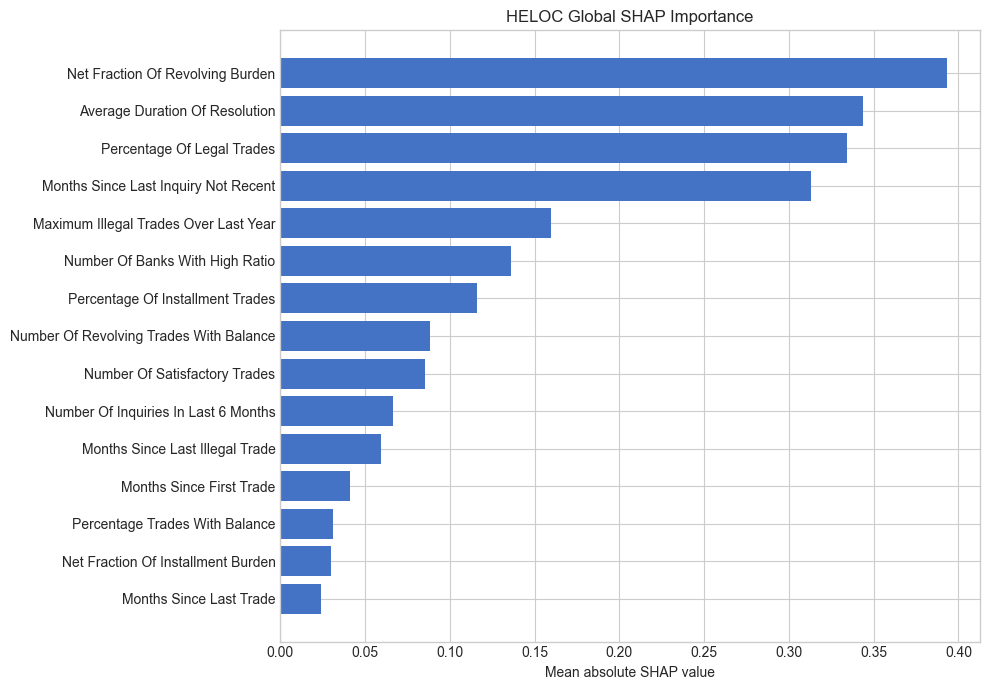

In [6]:
feature_positions = {feature: transformed_mapping.index[transformed_mapping.original_feature.eq(feature)].to_numpy() for feature in selected_features}
shap_original = np.column_stack([shap_transformed[:, feature_positions[feature]].sum(axis=1) for feature in selected_features])
assert shap_original.shape == (1_974, 22)
display_lookup = transformed_mapping.drop_duplicates("original_feature").set_index("original_feature").display_feature.to_dict()

transformed_importance = transformed_mapping.copy()
transformed_importance["mean_abs_shap"] = np.abs(shap_transformed).mean(axis=0)
transformed_importance = transformed_importance.sort_values("mean_abs_shap", ascending=False)
transformed_importance.to_csv(ARTIFACT_DIR / "shap_transformed_importance.csv", index=False)
global_importance = pd.DataFrame({"original_feature": selected_features,
    "display_feature": [display_lookup[f] for f in selected_features], "mean_abs_shap": np.abs(shap_original).mean(axis=0)}).sort_values("mean_abs_shap", ascending=False)
global_importance.to_csv(ARTIFACT_DIR / "shap_global_importance.csv", index=False)
display(global_importance.head(10))

plot_data = global_importance.head(15).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(10, 7)); ax.barh(plot_data.display_feature, plot_data.mean_abs_shap, color="#4472C4")
ax.set(title="HELOC Global SHAP Importance", xlabel="Mean absolute SHAP value", ylabel="")
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_shap_global_importance.png", dpi=300); plt.show()

## 7. Local explanations and top factors

Local directions describe changes in the model's at-risk output, not causal effects. Unverified negative codes are displayed only as special codes.

In [7]:
def raw_display(value):
    numeric = float(value)
    return f"special code {int(numeric)}" if numeric in SPECIAL_CODES else f"{numeric:g}"

local_rows = []
for case in xai_cases.itertuples(index=False):
    position = position_lookup[int(case.row_index)]; raw_row = X_test_raw.loc[case.row_index]
    contributions = shap_original[position]; order = np.argsort(-np.abs(contributions)); ranks = np.empty(len(selected_features), int); ranks[order] = np.arange(1, len(selected_features) + 1)
    for feature_position, feature in enumerate(selected_features):
        value = raw_row[feature]; shap_value = float(contributions[feature_position]); special = int(value) if value in SPECIAL_CODES else np.nan
        local_rows.append({"case_id": case.case_id, "row_index": int(case.row_index), "true_target": int(case.true_target),
            "predicted_class": int(case.predicted_class), "predicted_probability": float(case.predicted_probability),
            "original_feature": feature, "display_feature": display_lookup[feature], "display_value": raw_display(value),
            "special_state": f"special code {int(value)} (meaning unverified)" if value in SPECIAL_CODES else "",
            "shap_value": shap_value,
            "direction": "increases model at-risk output" if shap_value > 0 else ("decreases model at-risk output" if shap_value < 0 else "no contribution"),
            "rank": int(ranks[feature_position])})
local_explanations = pd.DataFrame(local_rows).sort_values(["case_id", "rank"])
top_factors = local_explanations.loc[local_explanations["rank"].le(5)].copy()
local_explanations.to_csv(ARTIFACT_DIR / "shap_local_explanations.csv", index=False)
top_factors.to_csv(ARTIFACT_DIR / "shap_top_factors.csv", index=False)
assert len(local_explanations) == 440 and len(top_factors) == 100
display(top_factors.head(10))

,case_id,row_index,true_target,predicted_class,predicted_probability,original_feature,display_feature,display_value,special_state,shap_value,direction,rank
2,HELOC_XAI_001,1991,1,1,0.948322,average_duration_of_resolution,Average Duration Of Resolution,25,,0.928052,increases model at-risk output,1
16,HELOC_XAI_001,1991,1,1,0.948322,net_fraction_of_revolving_burden,Net Fraction Of Revolving Burden,98,,0.798803,increases model at-risk output,2
12,HELOC_XAI_001,1991,1,1,0.948322,percentage_of_installment_trades,Percentage Of Installment Trades,75,,0.419321,increases model at-risk output,3
3,HELOC_XAI_001,1991,1,1,0.948322,number_of_satisfactory_trades,Number Of Satisfactory Trades,4,,0.273302,increases model at-risk output,4
13,HELOC_XAI_001,1991,1,1,0.948322,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,0,,0.200205,increases model at-risk output,5
24,HELOC_XAI_002,9808,1,1,0.945186,average_duration_of_resolution,Average Duration Of Resolution,19,,0.876246,increases model at-risk output,1
38,HELOC_XAI_002,9808,1,1,0.945186,net_fraction_of_revolving_burden,Net Fraction Of Revolving Burden,83,,0.742137,increases model at-risk output,2
34,HELOC_XAI_002,9808,1,1,0.945186,percentage_of_installment_trades,Percentage Of Installment Trades,70,,0.408376,increases model at-risk output,3
35,HELOC_XAI_002,9808,1,1,0.945186,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,0,,0.242714,increases model at-risk output,4
25,HELOC_XAI_002,9808,1,1,0.945186,number_of_satisfactory_trades,Number Of Satisfactory Trades,10,,0.166398,increases model at-risk output,5


## 8. Concise case explanations

Each narrative uses the two strongest persisted factors. Special states remain explicitly unverified.

In [8]:
plain_rows = []
for case in xai_cases.itertuples(index=False):
    factors = top_factors.loc[top_factors.case_id.eq(case.case_id)].sort_values("rank").head(2)
    statements = []
    for factor in factors.itertuples(index=False):
        verb = "increased" if factor.shap_value > 0 else "reduced"
        if factor.special_state:
            statements.append(f"{factor.display_feature} was recorded with {factor.display_value}, which {verb} the model's at-risk output")
        else:
            statements.append(f"{factor.display_feature} ({factor.display_value}) {verb} the model's at-risk output")
    plain_rows.append({"case_id": case.case_id, "explanation": "; while ".join(statements) + ". These are model associations, not causal effects."})
plain_english = pd.DataFrame(plain_rows)
plain_english.to_csv(ARTIFACT_DIR / "shap_plain_english.csv", index=False)
display(plain_english.head())

,case_id,explanation
0,HELOC_XAI_001,Average Duration Of Resolution (25) increased ...
1,HELOC_XAI_002,Average Duration Of Resolution (19) increased ...
2,HELOC_XAI_003,Average Duration Of Resolution (26) increased ...
3,HELOC_XAI_004,Average Duration Of Resolution (15) increased ...
4,HELOC_XAI_005,Average Duration Of Resolution (25) increased ...


## 9. Representative case

`HELOC_XAI_001` is used deterministically. The chart shows its strongest original-feature contributions in raw-margin units.

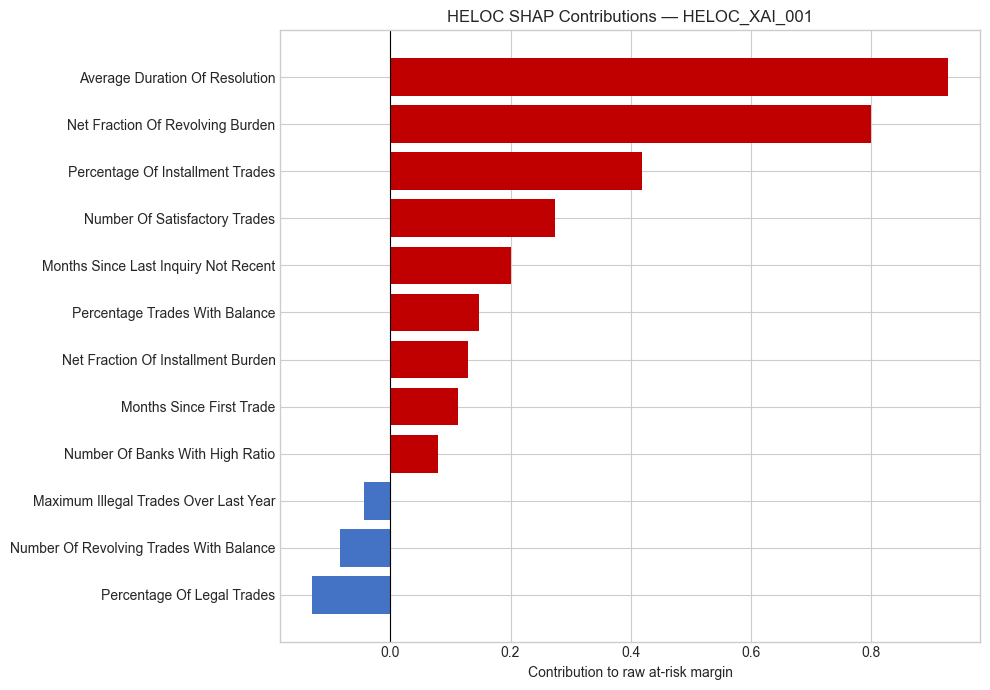

In [9]:
representative_id = "HELOC_XAI_001"; representative = xai_cases.loc[xai_cases.case_id.eq(representative_id)].iloc[0]
rep = local_explanations.loc[local_explanations.case_id.eq(representative_id)].sort_values("rank").head(12).sort_values("shap_value")
colors = np.where(rep.shap_value >= 0, "#C00000", "#4472C4")
fig, ax = plt.subplots(figsize=(10, 7)); ax.barh(rep.display_feature, rep.shap_value, color=colors); ax.axvline(0, color="black", linewidth=0.8)
ax.set(title=f"HELOC SHAP Contributions — {representative_id}", xlabel="Contribution to raw at-risk margin", ylabel="")
plt.tight_layout(); plt.savefig(PLOT_DIR / "heloc_shap_representative_waterfall.png", dpi=300); plt.show()

## 10. SHAP concentration

Concentration records how many original features account for 50% and 80% of absolute local attribution.

In [10]:
sparsity_rows = []
for case in xai_cases.itertuples(index=False):
    values = np.sort(np.abs(shap_original[position_lookup[int(case.row_index)]]))[::-1]; total = values.sum(); cumulative = np.cumsum(values) / total
    sparsity_rows.append({"case_id": case.case_id, "non_zero_feature_count": int((values > 1e-12).sum()),
        "features_for_50_percent": int(np.searchsorted(cumulative, .5) + 1), "features_for_80_percent": int(np.searchsorted(cumulative, .8) + 1)})
sparsity = pd.DataFrame(sparsity_rows); sparsity.to_csv(ARTIFACT_DIR / "shap_sparsity_metrics.csv", index=False)
display(sparsity[["features_for_50_percent", "features_for_80_percent"]].describe().loc[["mean", "50%", "min", "max"]])

,features_for_50_percent,features_for_80_percent
mean,3.1,6.5
50%,3.0,6.0
min,2.0,5.0
max,4.0,9.0


## 11. Preliminary local perturbation stability

Revolving burden is perturbed by approximately 1% of its valid training IQR, rounded to an integer step and bounded to the valid training range. This is a preliminary diagnostic rather than a robustness guarantee.

In [11]:
def explain_rows(frame):
    processed = preprocessor.transform(frame[selected_features]); transformed = booster.predict(xgb.DMatrix(processed, feature_names=transformed_names.tolist()), pred_contribs=True)[:, :-1]
    aggregated = np.column_stack([transformed[:, feature_positions[feature]].sum(axis=1) for feature in selected_features])
    return aggregated, model.predict_proba(processed)[:, 1]

stability_feature = "net_fraction_of_revolving_burden"
valid_training = X_train_raw.loc[~X_train_raw[stability_feature].isin(SPECIAL_CODES), stability_feature]
training_min, training_max = float(valid_training.min()), float(valid_training.max())
step = max(1.0, float(round((valid_training.quantile(.75) - valid_training.quantile(.25)) * .01)))
stability_rows = []
for case in xai_cases.head(5).itertuples(index=False):
    row = X_test_raw.loc[[case.row_index], selected_features].copy(); original = float(row.iloc[0][stability_feature]); assert original not in SPECIAL_CODES
    perturbed = min(original + step, training_max)
    if np.isclose(perturbed, original): perturbed = max(original - step, training_min)
    changed = row.copy(); changed.loc[case.row_index, stability_feature] = perturbed
    changed_shap, _ = explain_rows(changed); original_values = shap_original[position_lookup[int(case.row_index)]]
    original_top = set(np.asarray(selected_features)[np.argsort(-np.abs(original_values))[:5]]); changed_top = set(np.asarray(selected_features)[np.argsort(-np.abs(changed_shap[0]))[:5]])
    overlap = len(original_top & changed_top)
    stability_rows.append({"case_id": case.case_id, "perturbed_feature": stability_feature, "original_value": original,
        "perturbed_value": perturbed, "top_5_overlap_count": overlap, "top_5_jaccard": overlap / len(original_top | changed_top)})
stability = pd.DataFrame(stability_rows); stability.to_csv(ARTIFACT_DIR / "shap_preliminary_stability.csv", index=False)
display(stability)

,case_id,perturbed_feature,original_value,perturbed_value,top_5_overlap_count,top_5_jaccard
0,HELOC_XAI_001,net_fraction_of_revolving_burden,98.0,99.0,5,1.0
1,HELOC_XAI_002,net_fraction_of_revolving_burden,83.0,84.0,5,1.0
2,HELOC_XAI_003,net_fraction_of_revolving_burden,61.0,62.0,5,1.0
3,HELOC_XAI_004,net_fraction_of_revolving_burden,100.0,101.0,5,1.0
4,HELOC_XAI_005,net_fraction_of_revolving_burden,90.0,91.0,5,1.0


## 12. Preliminary intervention-based sensitivity

The highest-ranked feature with an ordinary value is replaced by its valid training median. This tests model sensitivity and is not causal evidence.

In [12]:
valid_training_medians = {feature: float(X_train_raw.loc[~X_train_raw[feature].isin(SPECIAL_CODES), feature].median()) for feature in selected_features}
faithfulness_rows = []
for case in xai_cases.head(5).itertuples(index=False):
    row = X_test_raw.loc[[case.row_index], selected_features].copy(); position = position_lookup[int(case.row_index)]
    ranked = np.argsort(-np.abs(shap_original[position])); top_feature = selected_features[ranked[0]]; intervened = replacement = None
    for feature_position in ranked:
        feature = selected_features[feature_position]; original = float(row.iloc[0][feature])
        if original in SPECIAL_CODES: continue
        candidate = valid_training_medians[feature]
        if not np.isclose(original, candidate): intervened, replacement = feature, candidate; break
    assert intervened is not None
    original_value = float(row.iloc[0][intervened]); changed = row.copy(); changed.loc[case.row_index, intervened] = replacement
    _, changed_probability = explain_rows(changed); changed_probability = float(changed_probability[0])
    faithfulness_rows.append({"case_id": case.case_id, "top_shap_feature": top_feature, "intervened_feature": intervened,
        "original_feature_value": original_value, "replacement_value": replacement, "feature_actually_changed": True,
        "original_probability": float(case.predicted_probability), "intervened_probability": changed_probability,
        "absolute_score_change": abs(changed_probability - float(case.predicted_probability)), "faithfulness_test_status": "completed"})
faithfulness = pd.DataFrame(faithfulness_rows); faithfulness.to_csv(ARTIFACT_DIR / "shap_preliminary_faithfulness.csv", index=False)
display(faithfulness)

,case_id,top_shap_feature,intervened_feature,original_feature_value,replacement_value,feature_actually_changed,original_probability,intervened_probability,absolute_score_change,faithfulness_test_status
0,HELOC_XAI_001,average_duration_of_resolution,average_duration_of_resolution,25.0,76.0,True,0.948322,0.870650,0.077672,completed
1,HELOC_XAI_002,average_duration_of_resolution,average_duration_of_resolution,19.0,76.0,True,0.945186,0.869519,0.075667,completed
2,HELOC_XAI_003,average_duration_of_resolution,average_duration_of_resolution,26.0,76.0,True,0.944068,0.881561,0.062507,completed
3,HELOC_XAI_004,average_duration_of_resolution,average_duration_of_resolution,15.0,76.0,True,0.941455,0.822812,0.118644,completed
4,HELOC_XAI_005,average_duration_of_resolution,average_duration_of_resolution,25.0,76.0,True,0.941175,0.888420,0.052755,completed


## 13. Metadata and final checks

The saved metadata records implementation, dimensions and numerical validation. The model and preprocessor remain frozen.

In [13]:
shap_metadata = {
    "dataset": "mstz/heloc risk configuration", "model_file": str(paths["model"].relative_to(PROJECT_ROOT)),
    "preprocessor_file": str(paths["preprocessor"].relative_to(PROJECT_ROOT)), "test_rows": len(X_test_raw),
    "explained_rows": len(shap_transformed), "original_selected_feature_count": len(selected_features),
    "transformed_feature_count": shap_transformed.shape[1], "fixed_xai_case_count": len(xai_cases),
    "shap_implementation": "XGBoost native Booster.predict(pred_contribs=True)", "model_output_space": "raw margin / log-odds",
    "base_value": float(base_values[0]), "max_raw_margin_additivity_error": max_margin_error,
    "max_probability_reconstruction_error": max_probability_error, "global_top_feature": global_importance.iloc[0].original_feature,
    "representative_case": representative_id, "stability_cases_tested": len(stability), "faithfulness_cases_tested": len(faithfulness),
    "special_code_semantics_verified": False, "model_retrained": False, "preprocessor_refitted": False,
}
(ARTIFACT_DIR / "shap_metadata.json").write_text(json.dumps(shap_metadata, indent=2), encoding="utf-8")

assert len(X_test_raw) == 1_974 and shap_transformed.shape == (1_974, 33) and shap_original.shape == (1_974, 22)
assert len(xai_cases) == 20 and len(local_explanations) == 440 and len(top_factors) == 100
assert len(plain_english) == len(sparsity) == 20 and len(stability) == len(faithfulness) == 5
assert faithfulness.feature_actually_changed.all()
print("Frozen model loaded: True"); print("Exact test rows reconstructed: 1974"); print("Frozen predictions reproduced: True")
print("SHAP explained rows: 1974"); print("Transformed SHAP shape: (1974, 33)"); print("Original aggregated SHAP shape: (1974, 22)")
print("Fixed XAI cases: 20"); print("Local explanation rows: 440"); print("Top-factor rows: 100"); print("Plain-English rows: 20")
print("Sparsity rows: 20"); print("Stability rows: 5"); print("Faithfulness rows: 5")
print("Model retrained: False"); print("Preprocessor refitted: False"); print("New split created: False")
print("LIME executed: False"); print("DiCE executed: False")

Frozen model loaded: True
Exact test rows reconstructed: 1974
Frozen predictions reproduced: True
SHAP explained rows: 1974
Transformed SHAP shape: (1974, 33)
Original aggregated SHAP shape: (1974, 22)
Fixed XAI cases: 20
Local explanation rows: 440
Top-factor rows: 100
Plain-English rows: 20
Sparsity rows: 20
Stability rows: 5
Faithfulness rows: 5
Model retrained: False
Preprocessor refitted: False
New split created: False
LIME executed: False
DiCE executed: False


## 14. Stage 06 hand-off

The SHAP artifacts are frozen for review. LIME and DiCE are not started here.